In [10]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style("darkgrid")
plt.rcParams.update({'font.size': 22})

# Qualitative evaluation experiments

In [3]:
train_x = pd.read_csv('../dataset/0-original/X.csv').drop('id', axis=1)
train_y = pd.read_csv('../dataset/0-original/y.csv').drop('id', axis=1)
train_y['trq_target'] = train_x['trq_measured'] / (train_y['trq_margin'] / 100 + 1)
train_df = pd.concat([train_x, train_y], axis=1)

valid_x = pd.read_csv('../dataset/0-original/X_validation.csv').drop('id', axis=1)
test_x = pd.read_csv('../dataset/0-original/X_test.csv').drop('id', axis=1)
valid_test_x = pd.concat([valid_x, test_x], ignore_index=True)
valid_test_y = pd.read_csv('../4-Qualitative_Evaluation/valid_test_y.csv')
test_df = pd.concat([valid_test_x, valid_test_y], axis=1)

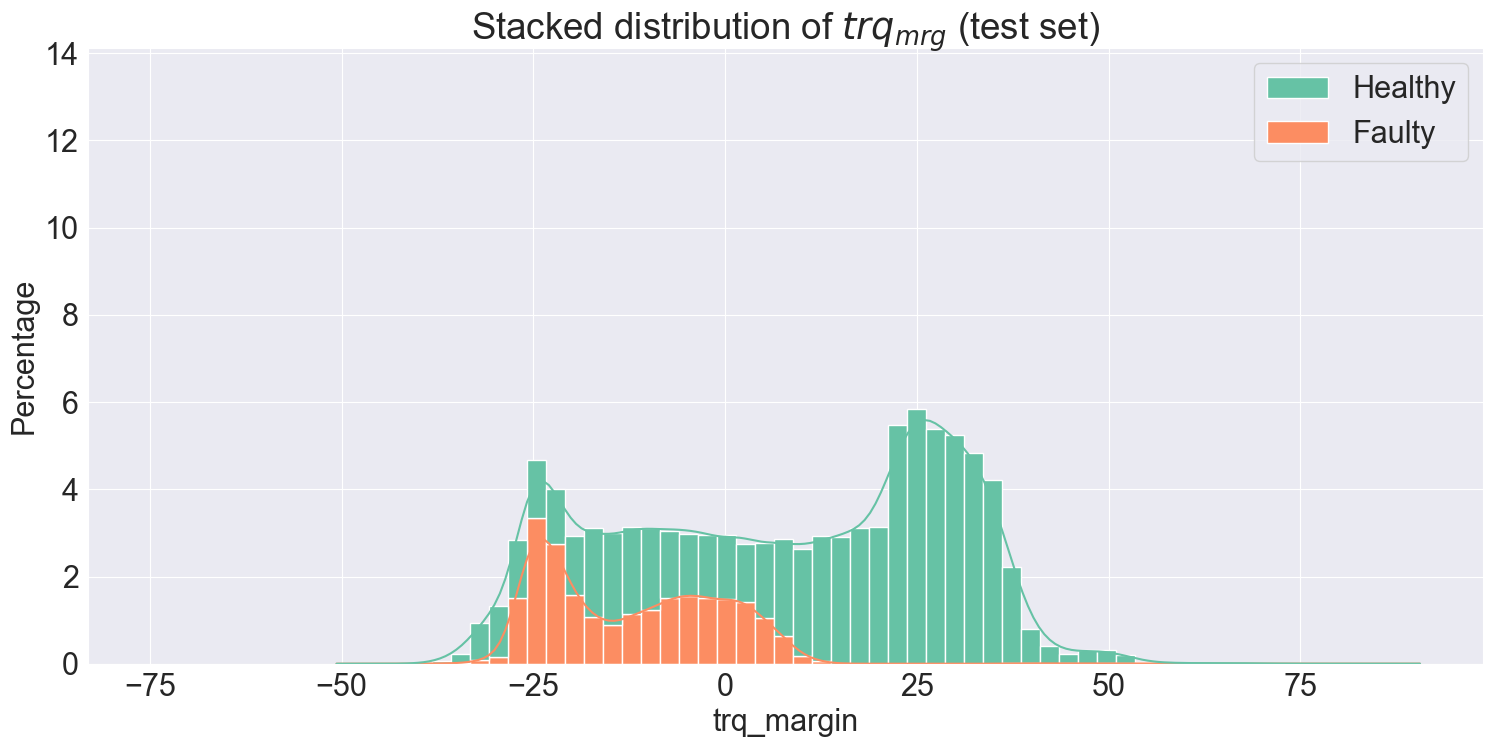

In [84]:
features = ['trq_margin', 'trq_measured', 'oat', 'mgt', 'pa', 'ias', 'np', 'ng']

for feature in features[:1]:
    plt.figure(figsize=(18, 8))
    faulty_distribution_train = pd.DataFrame({'Healthy': train_df[train_df['faulty'] < 0.5][feature],
                                        'Faulty': train_df[train_df['faulty'] > 0.5][feature], })
    faulty_distribution_test = pd.DataFrame({'Healthy': test_df[test_df['faulty'] < 0.5][feature],
                                        'Faulty': test_df[test_df['faulty'] > 0.5][feature], })


    # ax=sns.histplot(train_df[feature], kde=False, color='blue', label="Training", alpha=0.0, bins=30, stat='percent')
    ax=sns.histplot(faulty_distribution_test, multiple='stack', kde=True, alpha=1,
                 binwidth=2.5, stat='percent', palette='Set2')
    ax.set_ylim(0.0, 14.12675307187342)
    ax.set_xlim(-83.01431764782924, 98.86423832672335)

    plt.title("Stacked distribution of $trq_{mrg}$ (test set)")
    plt.xlabel(feature)
    plt.ylabel("Percentage")
    plt.show()

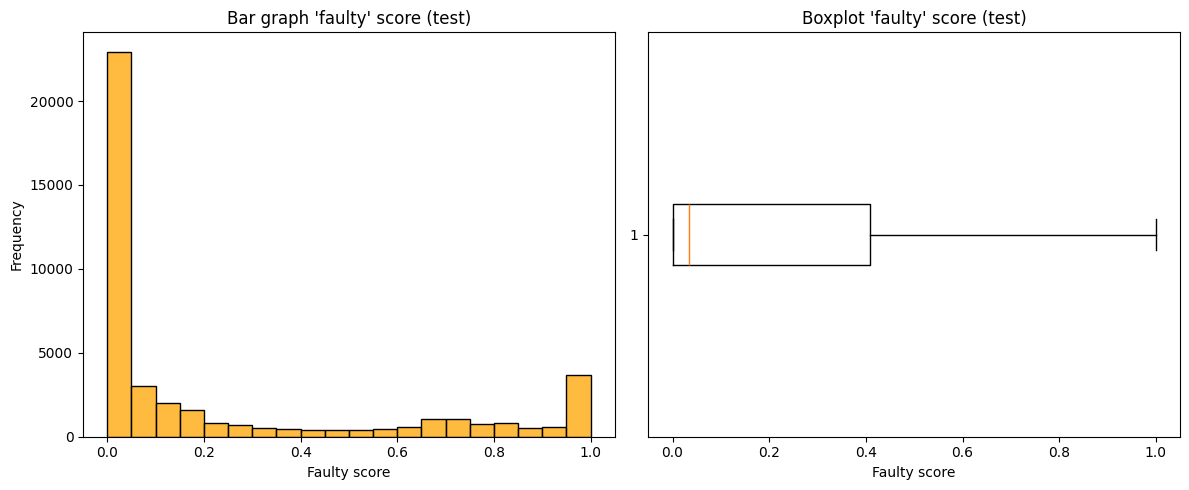

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(test_df['faulty'], bins=20, color='orange', edgecolor='black')
plt.title("Bar graph 'faulty' score (test)")
plt.xlabel("Faulty score")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.boxplot(test_df['faulty'], vert=False)
plt.title("Boxplot 'faulty' score (test)")
plt.xlabel("Faulty score")
plt.tight_layout()
plt.show()

In [ ]:
#Correlation
corr_train = train_df[features + ['faulty']].corr()
print("Corr. (training) between features and 'faulty':")
print(corr_train['faulty'])

corr_test = test_df[features + ['faulty']].corr()
print("\nCorr. (test) between feature and 'faulty confidence':")
print(corr_test['faulty'])

threshold = 0.5
test_df['faulty_bin'] = (test_df['faulty'] >= threshold).astype(int)

corr_bin = test_df[['trq_margin', 'trq_measured', 'oat', 'mgt', 'pa', 'ias', 'np', 'ng', 'faulty_bin']].corr()
print("Corr. (test) between feature and faulty_bin:")
print(corr_bin['faulty_bin'])

Corr. (training) between features and 'faulty':
trq_margin     -0.605112
trq_measured   -0.132677
oat            -0.338451
mgt             0.184274
pa              0.342304
ias            -0.108341
np              0.134411
ng             -0.090337
faulty          1.000000
Name: faulty, dtype: float64

Corr. (test) tra le feature e 'faulty confidence':
trq_margin     -0.586426
trq_measured   -0.548833
oat             0.275325
mgt            -0.498513
pa              0.204542
ias            -0.287436
np             -0.069957
ng             -0.535221
faulty          1.000000
Name: faulty, dtype: float64
Corr. (test) cwith faulty_bin:
trq_margin     -0.495550
trq_measured   -0.455660
oat             0.209731
mgt            -0.414835
pa              0.217671
ias            -0.234513
np             -0.041427
ng             -0.452702
faulty_bin      1.000000
Name: faulty_bin, dtype: float64


Ci sono differenze nelle correlazioni, sembra che alcune feature abbiamo maggiore importanza nel test rispetto al training.

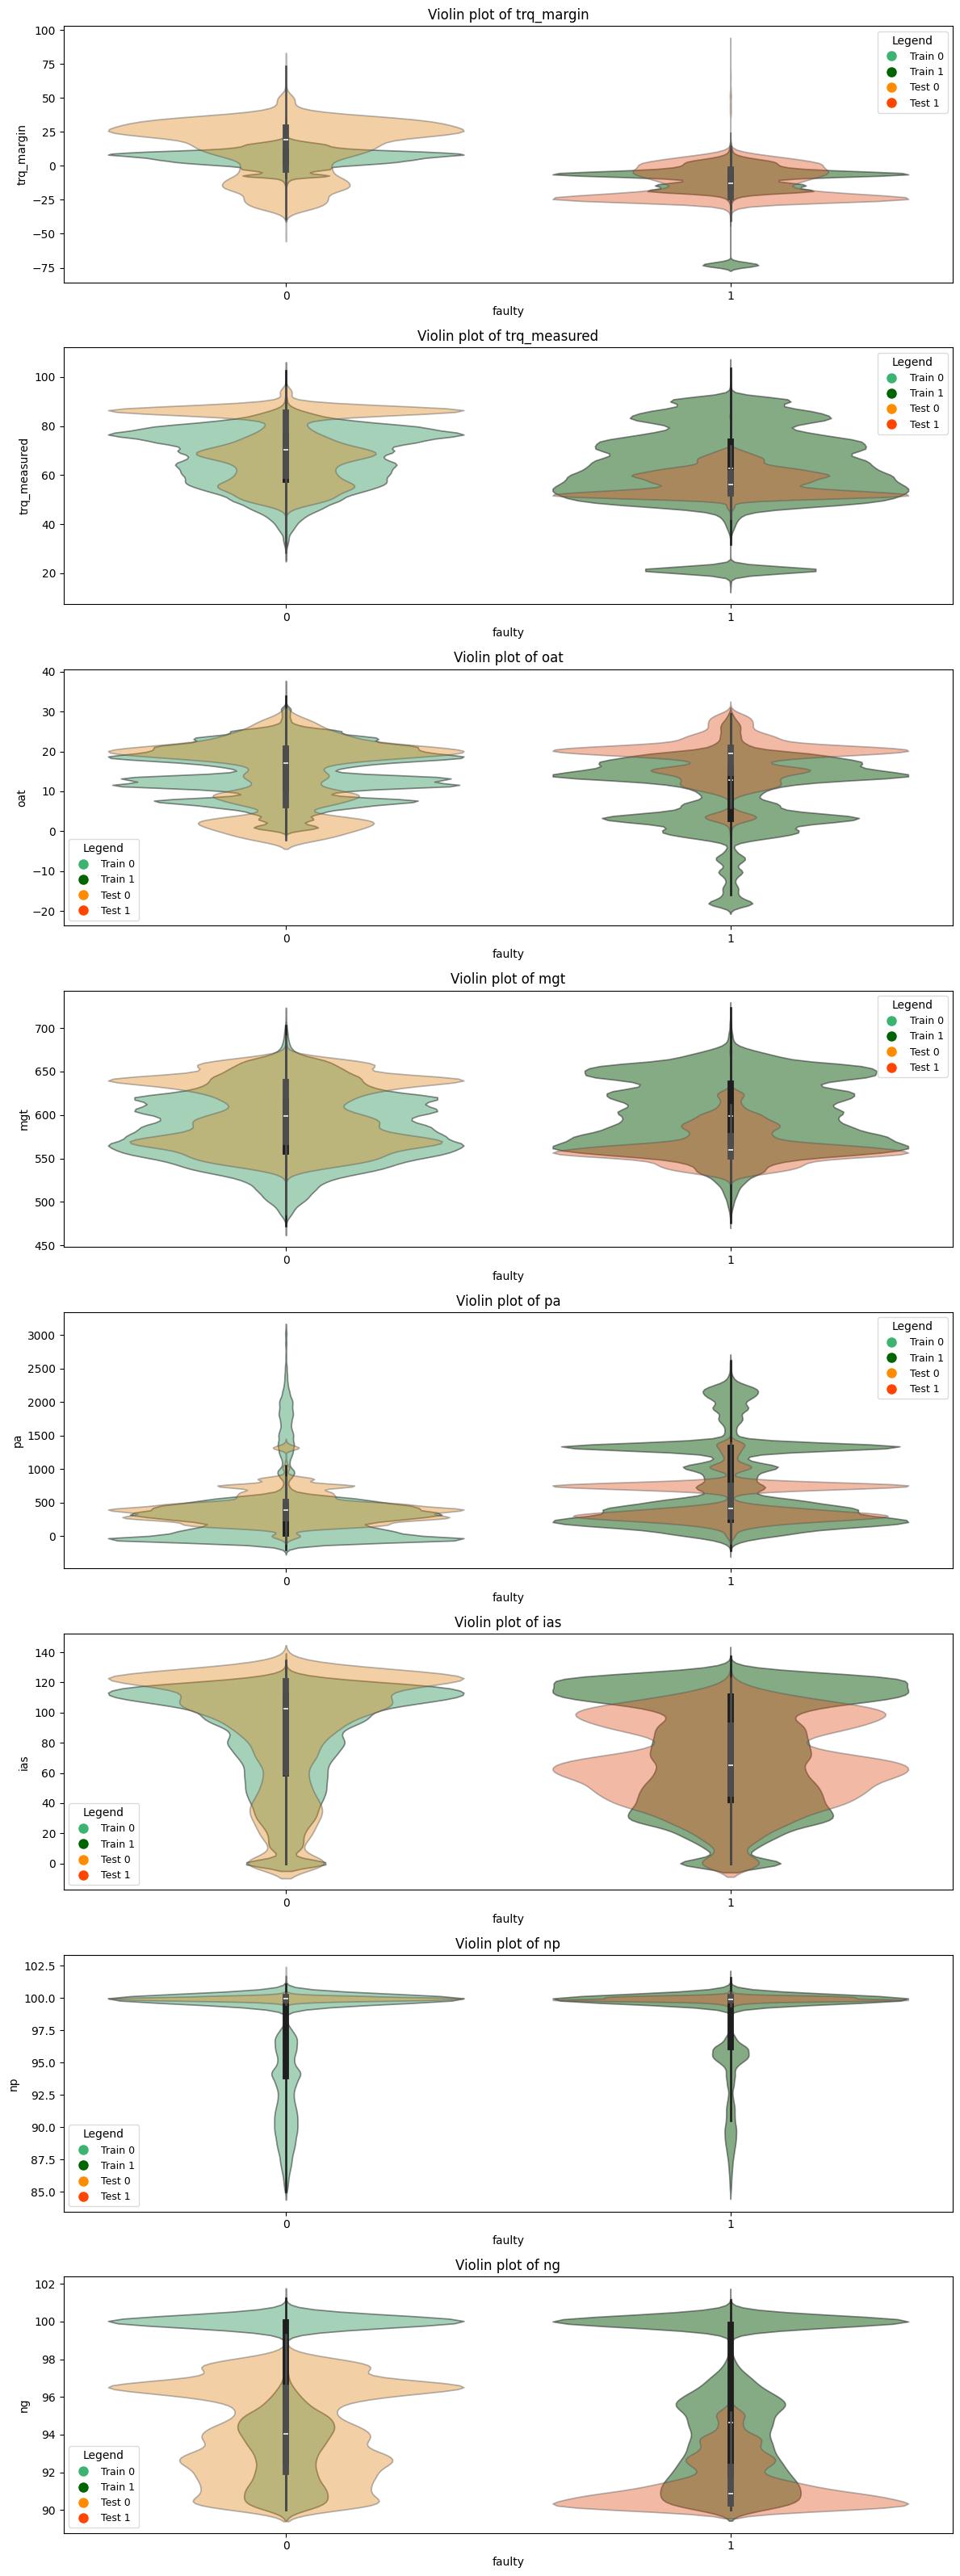

In [25]:
custom_palette_train = {0: 'mediumseagreen', 1: 'darkgreen'}
custom_palette_test = {0: 'darkorange', 1: 'orangered'}
num_features = len(features)
fig, axes = plt.subplots(nrows=num_features, ncols=1, figsize=(12, 4 * num_features))

for i, feature in enumerate(features):
    ax = axes[i]

    sns.violinplot(
        ax=ax,
        x='faulty',
        y=feature,
        data=train_df,
        hue='faulty',
        palette=custom_palette_train,
        alpha=0.5,
        legend=False
    )

    sns.violinplot(
        ax=ax,
        x='faulty_bin',
        y=feature,
        data=test_df,
        hue='faulty_bin',
        palette=custom_palette_test,
        alpha=0.4,
        legend=False
    )

    marker_train0 = mlines.Line2D([], [], color=custom_palette_train[0], marker='o', linestyle='None', markersize=8,
                                  label='Train 0')
    marker_train1 = mlines.Line2D([], [], color=custom_palette_train[1], marker='o', linestyle='None', markersize=8,
                                  label='Train 1')
    marker_test0 = mlines.Line2D([], [], color=custom_palette_test[0], marker='o', linestyle='None', markersize=8,
                                 label='Test 0')
    marker_test1 = mlines.Line2D([], [], color=custom_palette_test[1], marker='o', linestyle='None', markersize=8,
                                 label='Test 1')

    legend = ax.legend(
        handles=[marker_train0, marker_train1, marker_test0, marker_test1],
        title="Legend",
        fontsize=9,
        title_fontsize=10,
        frameon=True,
        framealpha=0.7,
        labelspacing=0.5
    )

    ax.set_title(f"Violin plot of {feature}")

plt.tight_layout()
plt.show()

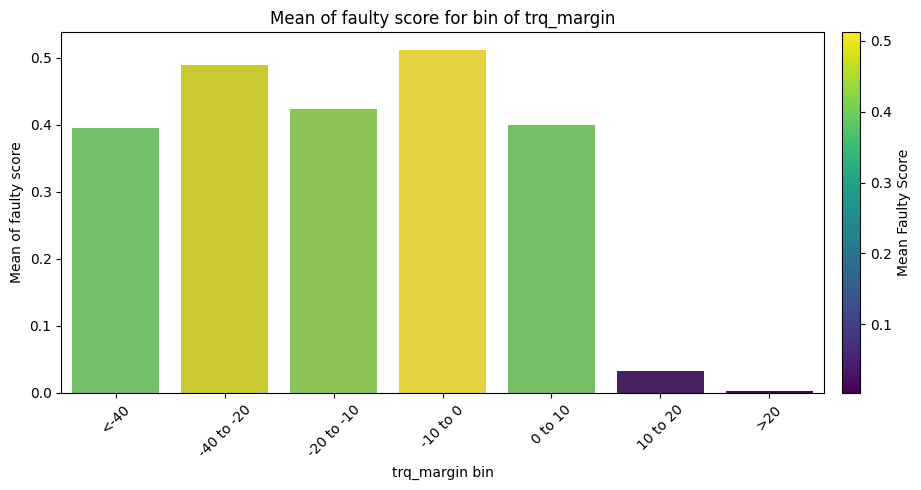

In [43]:
#Biiiiin
bins = [-float('inf'), -40, -20, -10, 0, 10, 20, float('inf')]
labels = ['<-40', '-40 to -20', '-20 to -10', '-10 to 0', '0 to 10', '10 to 20', '>20']
test_df['trq_margin_bin'] = pd.cut(test_df['trq_margin'], bins=bins, labels=labels)
avg_faulty_by_bin = test_df.groupby('trq_margin_bin', observed=False)['faulty'].mean().reset_index()
norm = mcolors.Normalize(vmin=avg_faulty_by_bin['faulty'].min(), vmax=avg_faulty_by_bin['faulty'].max())
cmap = plt.colormaps.get_cmap('viridis')
colors = [cmap(norm(value)) for value in avg_faulty_by_bin['faulty']]
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x='trq_margin_bin',
    y='faulty',
    data=avg_faulty_by_bin,
    hue='trq_margin_bin',
    palette=colors,
    legend=False,
    ax=ax
)

ax.set_title("Mean of faulty score for bin of trq_margin")
ax.set_xlabel("trq_margin bin")
ax.set_ylabel("Mean of faulty score")

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label("Mean Faulty Score")

plt.tight_layout()
plt.show()

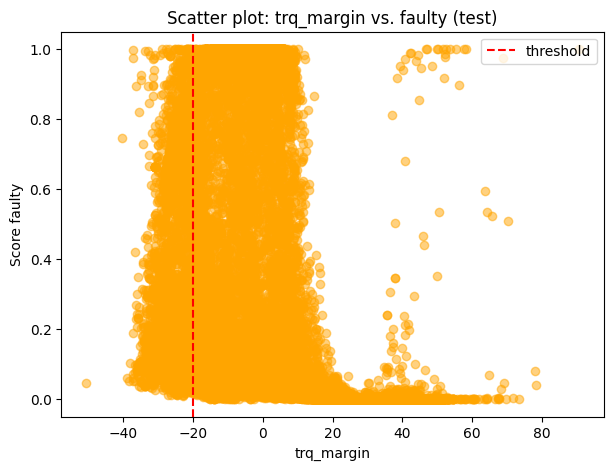

In [44]:
plt.figure(figsize=(7, 5))
plt.scatter(test_df['trq_margin'], test_df['faulty'], alpha=0.5, color='orange')
plt.title("Scatter plot: trq_margin vs. faulty (test)")
plt.xlabel("trq_margin")
plt.ylabel("Score faulty")
plt.axvline(x=-20, color='red', linestyle='--', label='threshold')
plt.legend()
plt.show()

più il valore di trq_margin è negativo, più è probabile che la confidence faulty sia alto, anche se non è un rapporto perfettamente lineare. Sopra lo 0 maggior parte dei punti ha faulty vicino a 0.

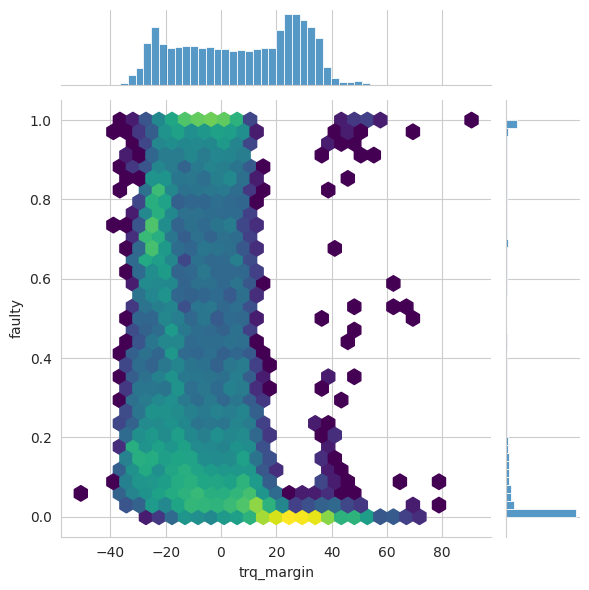

In [ ]:
sns.jointplot(
    data=test_df, x='trq_margin', y='faulty',
    kind='hex', gridsize=30, cmap='viridis',
    marginal_kws=dict(bins=50),
    joint_kws=dict(bins='log')
)

*   colori chiari = maggiore densità di punti
*   colori scuri = minore densità di punti


*   distribuzione in alto -> trq_margin
*   distribuzione laterale -> faulty

In [29]:
# Outlier analysis
train_df['trq_target'] = train_df['trq_measured'] / (1 + train_df['trq_margin'] / 100)
test_df['trq_target'] = test_df['trq_measured'] / (1 + test_df['trq_margin'] / 100)

q1_train = train_df['trq_margin'].quantile(0.25)
q3_train = train_df['trq_margin'].quantile(0.75)
iqr_train = q3_train - q1_train
lower_bound_train = q1_train - 1.5 * iqr_train
upper_bound_train = q3_train + 1.5 * iqr_train
train_outliers = train_df[(train_df['trq_margin'] < lower_bound_train) | (train_df['trq_margin'] > upper_bound_train)]
print("N. of outlier in trq_margin (training):", len(train_outliers))
print(train_outliers[['id', 'trq_margin', 'trq_target', 'trq_measured', 'faulty']].head())

q1_test = test_df['trq_margin'].quantile(0.25)
q3_test = test_df['trq_margin'].quantile(0.75)
iqr_test = q3_test - q1_test
lower_bound_test = q1_test - 1.5 * iqr_test
upper_bound_test = q3_test + 1.5 * iqr_test
test_outliers = test_df[(test_df['trq_margin'] < lower_bound_test) | (test_df['trq_margin'] > upper_bound_test)]
print("N. of outliers in trq_margin (test):", len(test_outliers))
print(test_outliers[['id', 'trq_margin', 'trq_target', 'trq_measured', 'faulty']].head())

N. of outlier in trq_margin (training): 15746
      id  trq_margin  trq_target  trq_measured  faulty
30    30  -71.712109   78.148103      22.10645       1
38    38  -72.819916   80.100855      21.77148       1
65    65  -71.476149   71.850851      20.49463       1
76    76  -72.336571   78.448916      21.70166       1
210  210  -71.728535   78.086403      22.07617       1
N. of outliers in trq_margin (test): 1
        id  trq_margin  trq_target  trq_measured    faulty
22189  753   90.597031   50.368046          96.0  0.999927


In [45]:
outlier_df = test_df[test_df['trq_margin'] > 80]

if not outlier_df.empty:
    for col in ['oat', 'trq_measured', 'mgt', 'pa', 'ias', 'np', 'ng']:
        val = outlier_df[col].values
        print(f"{col} for the outlier: {val}")

        q_low = test_df[col].quantile(0.05)
        q_high = test_df[col].quantile(0.95)
        print(f"Range 5-95% of '{col}' on test set: {q_low} - {q_high}\n")

oat for the outlier: [19.5]
Range 5-95% of 'oat' on test set: 0.0 - 25.75

trq_measured for the outlier: [96.]
Range 5-95% of 'trq_measured' on test set: 50.7 - 87.3

mgt for the outlier: [671.]
Range 5-95% of 'mgt' on test set: 542.955 - 656.9

pa for the outlier: [187.7568]
Range 5-95% of 'pa' on test set: 144.78 - 855.4059599999991

ias for the outlier: [27.25]
Range 5-95% of 'ias' on test set: 3.8468750000000114 - 125.625

np for the outlier: [100.24]
Range 5-95% of 'np' on test set: 99.69 - 100.22

ng for the outlier: [98.65]
Range 5-95% of 'ng' on test set: 90.18 - 97.58



Non è solo trq_margin a essere fuori scala: anche mgt, np e ng risultano superiori ai valori del 95°-> il motore potrebbe trovarsi in condizioni operative anomale